In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def annotate_faces(img, detected_faces):
    thickness = 2
    draw_img = img.copy()
    if detected_faces is not None:
        for idx, face in enumerate(detected_faces):
            coords = face[:-1].astype(np.int32)
            cv.rectangle(draw_img, (coords[0], coords[1]), (coords[0] + coords[2], coords[1] + coords[3]), (0, 255, 0),
                         thickness)
            left_eye = (coords[4], coords[5])
            right_eye = (coords[6], coords[7])
            nose = (coords[8], coords[9])
            lip_left_corner = (coords[10], coords[11])
            lip_right_corner = (coords[12], coords[13])
            cv.circle(draw_img, left_eye, 2, (255, 0, 0), thickness)
            cv.circle(draw_img, right_eye, 2, (0, 0, 255), thickness)
            cv.circle(draw_img, nose, 2, (0, 255, 0), thickness)
            cv.circle(draw_img, lip_left_corner, 2, (255, 0, 255), thickness)
            cv.circle(draw_img, lip_right_corner, 2, (0, 255, 255), thickness)

    plt.imshow(draw_img[..., ::-1])
    plt.show()

In [7]:
img1 = cv.imread("../../images/cr7_red.png")
img2 = cv.imread("../../images/cr7_blue.png")

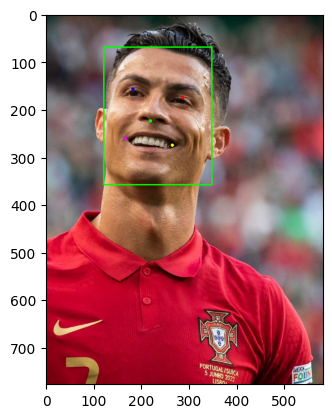

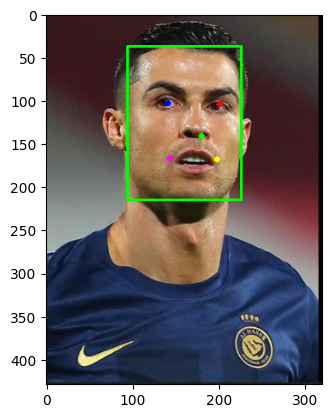

In [8]:
detector = cv.FaceDetectorYN.create(
    "../assays/a17_deep-learning-with-opencv/face_detection_yunet_2023mar.onnx",
    "",
    (320, 320),
    0.9,
    0.3,
    5000
)

detector.setInputSize(img1.shape[:2][::-1])
detected_faces1 = detector.detect(img1)[1]
annotate_faces(img1, detected_faces1)

detector.setInputSize(img2.shape[:2][::-1])
detected_faces2 = detector.detect(img2)[1]
annotate_faces(img2, detected_faces2)

In [9]:
recognizer = cv.FaceRecognizerSF.create(
    "../../../class.vision/model/face/face_recognition_sface_2021dec.onnx", "")

Text(0.5, 1.0, '')

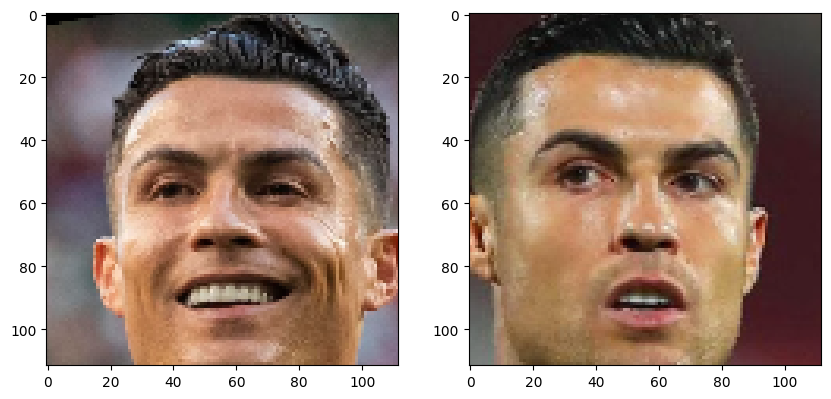

In [10]:
img1_align = recognizer.alignCrop(img1, detected_faces1[0])
img2_align = recognizer.alignCrop(img2, detected_faces2[0])

plt.figure(figsize=(10,6))
plt.subplot(121); plt.imshow(img1_align[...,::-1]); plt.title("")
plt.subplot(122); plt.imshow(img2_align[...,::-1]); plt.title("")

In [11]:
face1_feature = recognizer.feature(img1_align)
face2_feature = recognizer.feature(img2_align)

print(face1_feature.shape)
print(face2_feature.shape)

(1, 128)
(1, 128)


In [12]:
l2_similarity_threshold = 1.128

l2_score = recognizer.match(face1_feature, face2_feature, cv.FaceRecognizerSF_FR_NORM_L2)

msg = 'different identities'
if l2_score <= l2_similarity_threshold:
    msg = 'the same identity'
print('They have {}. NormL2 Distance: {}, threshold: {} (lower value means higher similarity, min 0.0).'.format(msg, l2_score, l2_similarity_threshold))

They have the same identity. NormL2 Distance: 0.7298386139634118, threshold: 1.128 (lower value means higher similarity, min 0.0).


In [13]:
cosine_similarity_threshold = 0.363

cosine_score = recognizer.match(face1_feature, face2_feature, cv.FaceRecognizerSF_FR_COSINE)

msg = 'different identities'
if cosine_score >= cosine_similarity_threshold:
    msg = 'the same identity'
print('They have {}. Cosine Similarity: {}, threshold: {} (higher value means higher similarity, max 1.0).'.format(msg, cosine_score, cosine_similarity_threshold))

They have the same identity. Cosine Similarity: 0.733667803522394, threshold: 0.363 (higher value means higher similarity, max 1.0).
